# Controlled Natural Language Generation
## Decoder vs LLM for Slot-Conditioned Response Generation
### Domain: E-Commerce Order Assistant

---

**Objective:** Build and compare two systems for generating natural language responses from structured slot inputs:
1. A lightweight custom Decoder-only Transformer trained from scratch
2. A modern LLM via prompt-based generation (Open API)

---

## Setup & Imports

In [1]:
# Install required packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q transformers datasets evaluate sacrebleu rouge-score bert-score openai nltk tqdm matplotlib seaborn pandas scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.2 MB/s eta 0:00:00


In [2]:
import json
import os
import random
import time
import math
import copy
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import nltk
from nltk.tokenize import word_tokenize
from rouge_score import rouge_scorer
import sacrebleu

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.11.0+cu128


---
# MODULE 1: Data Preparation & Input Representation

---

## Task 1: Dataset Construction & Schema Design

### 1.1 Intent-Slot Schema

We define a fixed **E-Commerce Order Assistant** domain with:
- **6 Intents**: `order_status`, `cancel_order`, `return_request`, `delivery_delay`, `payment_status`, `refund_status`
- **Slot Types**: `order_id`, `status`, `date`, `item`, `reason`, `tracking_id`, `carrier`, `eta`, `cause`, `compensation`, `payment_status`, `amount`, `method`, `transaction_id`, `refund_id`, `refund_status`, `pickup_date`, `return_id`

### Why this schema?
The E-Commerce domain is well-suited for controlled NLG because:
- Responses are factual and slot-anchored (users expect precise info)
- Intents are well-separated with distinct slot profiles
- Edge cases (missing slots, optional fields) are natural and frequent
- Measurable correctness: a wrong order ID is clearly wrong

### Dataset Source
The dataset is loaded from `dataset_full.csv` which contains pre-built intent-slot-response triplets for the e-commerce domain.

In [3]:
# SCHEMA DEFINITION

SCHEMA = {
    'intents': {
        'order_status': {
            'required_slots': ['order_id', 'status'],
            'optional_slots': ['date', 'tracking_id', 'carrier'],
            'description': 'Query about current status of an order'
        },
        'cancel_order': {
            'required_slots': ['order_id'],
            'optional_slots': ['reason', 'refund_status', 'date'],
            'description': 'Request to cancel an existing order'
        },
        'return_request': {
            'required_slots': ['order_id', 'item'],
            'optional_slots': ['reason', 'method', 'pickup_date', 'return_id'],
            'description': 'Request to return a purchased product'
        },
        'delivery_delay': {
            'required_slots': ['order_id', 'eta'],
            'optional_slots': ['cause', 'carrier', 'compensation'],
            'description': 'Notification about delivery delay'
        },
        'payment_status': {
            'required_slots': ['order_id', 'payment_status'],
            'optional_slots': ['amount', 'method', 'transaction_id', 'date'],
            'description': 'Query about payment status or details'
        },
        'refund_status': {
            'required_slots': ['refund_id', 'order_id', 'refund_status'],
            'optional_slots': ['amount', 'date', 'method'],
            'description': 'Query about refund status'
        }
    },
    'slots': {
        'order_id':        {'type': 'string', 'example': '1234'},
        'status':          {'type': 'categorical', 'values': ['placed', 'packed', 'shipped', 'out for delivery', 'delivered']},
        'date':            {'type': 'date', 'example': '3 May'},
        'item':            {'type': 'string', 'example': 'running shoes'},
        'reason':          {'type': 'categorical', 'values': ['wrong size', 'damaged item', 'late delivery', 'duplicate order', 'change of mind']},
        'tracking_id':     {'type': 'string', 'example': 'TRK9999'},
        'carrier':         {'type': 'string', 'example': 'FedEx'},
        'eta':             {'type': 'date', 'example': '5 May'},
        'cause':           {'type': 'string', 'example': 'weather disruption'},
        'compensation':    {'type': 'string', 'example': 'free shipping next time'},
        'payment_status':  {'type': 'categorical', 'values': ['pending', 'successful', 'reversed']},
        'amount':          {'type': 'currency', 'example': '₹1,249'},
        'method':          {'type': 'categorical', 'values': ['drop-off', 'mail-in', 'pickup']},
        'transaction_id':  {'type': 'string', 'example': 'TXN12345'},
        'refund_id':       {'type': 'string', 'example': 'RF1001'},
        'refund_status':   {'type': 'categorical', 'values': ['pending', 'approved', 'processed', 'completed']},
        'pickup_date':     {'type': 'date', 'example': 'next Monday'},
        'return_id':       {'type': 'string', 'example': 'RET2001'}
    }
}

print("Schema defined (based on dataset_full.csv):")
print(f"  Intents: {list(SCHEMA['intents'].keys())}")
print(f"  Slots:   {list(SCHEMA['slots'].keys())}")

Schema defined (based on dataset_full.csv):
  Intents: ['order_status', 'cancel_order', 'return_request', 'delivery_delay', 'payment_status', 'refund_status']
  Slots:   ['order_id', 'status', 'date', 'item', 'reason', 'tracking_id', 'carrier', 'eta', 'cause', 'compensation', 'payment_status', 'amount', 'method', 'transaction_id', 'refund_id', 'refund_status', 'pickup_date', 'return_id']


In [4]:
# LOAD DATASET FROM CSV

# Load the pre-built dataset from CSV
df_full = pd.read_csv('dataset_full.csv')

# Convert CSV rows to the expected format
dataset = []
for _, row in df_full.iterrows():
    # Parse the JSON string in slots_json column
    slots_dict = json.loads(row['slots_json'])

    dataset.append({
        'intent': row['intent'],
        'slots': slots_dict,
        'response': row['reference_response'],
        'is_edge_case': row['is_edge_case']
    })

print(f"Loaded {len(dataset)} samples from dataset_full.csv")
print("\nSample example:")
print(json.dumps(dataset[0], indent=2))
print("\nDataset contains the following intents:")
intent_counts = pd.Series([s['intent'] for s in dataset]).value_counts()
print(intent_counts)

# Extract unique slot values for evaluation utilities
ORDER_IDS = []
TRACKING_IDS = []
for sample in dataset:
    if 'order_id' in sample['slots']:
        ORDER_IDS.append(sample['slots']['order_id'])
    if 'tracking_id' in sample['slots']:
        TRACKING_IDS.append(sample['slots']['tracking_id'])
ORDER_IDS = list(set(ORDER_IDS))
TRACKING_IDS = list(set(TRACKING_IDS))

print(f"\nExtracted {len(ORDER_IDS)} unique order IDs and {len(TRACKING_IDS)} unique tracking IDs")

Loaded 324 samples from dataset_full.csv

Sample example:
{
  "intent": "return_request",
  "slots": {
    "order_id": "1234",
    "item": "coffee maker",
    "reason": "wrong size",
    "pickup_date": "next Monday"
  },
  "response": "I created a return request for coffee maker under order 1234 because wrong size; pickup is scheduled for next Monday.",
  "is_edge_case": true
}

Dataset contains the following intents:
return_request    54
order_status      54
delivery_delay    54
payment_status    54
refund_status     54
cancel_order      54
Name: count, dtype: int64

Extracted 5 unique order IDs and 3 unique tracking IDs


In [5]:
# TRAIN / VAL / TEST SPLIT (70 / 15 / 15)

# Shuffle dataset before split
random.shuffle(dataset)

n = len(dataset)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_data = dataset[:n_train]
val_data = dataset[n_train:n_train + n_val]
test_data = dataset[n_train + n_val:]

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# Save dataset
os.makedirs('data', exist_ok=True)
with open('data/train.json', 'w') as f: json.dump(train_data, f, indent=2)
with open('data/val.json',   'w') as f: json.dump(val_data,   f, indent=2)
with open('data/test.json',  'w') as f: json.dump(test_data,  f, indent=2)
with open('data/schema.json','w') as f: json.dump(SCHEMA,     f, indent=2)
print("Saved dataset files to data/")

Train: 226 | Val: 48 | Test: 50
Saved dataset files to data/


=== Dataset Statistics ===
Total samples     : 324
Edge cases        : 263 (81.2%)
Avg response len  : 12.7 words
Avg slots per sample: 4.0

                count  avg_slots  avg_resp_len
intent                                        
cancel_order       54       3.11         11.13
delivery_delay     54       3.67         15.46
order_status       54       3.44          7.24
payment_status     54       4.69         12.61
refund_status      54       4.54         10.89
return_request     54       4.44         18.57


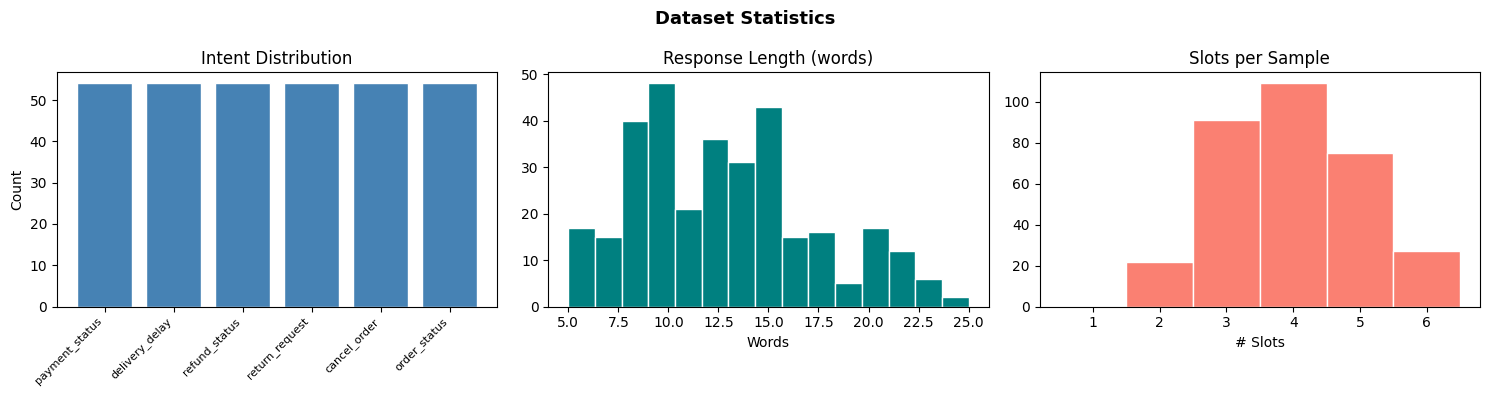

Saved dataset_stats.png

=== Slot Coverage ===


,Slot,Count
0,order_id,324
1,date,119
2,reason,108
3,amount,82
4,refund_status,80
5,method,79
6,payment_status,54
7,eta,54
8,refund_id,54
9,item,54


In [6]:
# DATASET STATISTICS

df = pd.DataFrame([
    {'intent': s['intent'],
     'n_slots': len(s['slots']),
     'response_len': len(s['response'].split()),
     'is_edge_case': s['is_edge_case']}
    for s in dataset
])

print("=== Dataset Statistics ===")
print(f"Total samples     : {len(dataset)}")
print(f"Edge cases        : {df['is_edge_case'].sum()} ({df['is_edge_case'].mean()*100:.1f}%)")
print(f"Avg response len  : {df['response_len'].mean():.1f} words")
print(f"Avg slots per sample: {df['n_slots'].mean():.1f}")
print()
print(df.groupby('intent').agg(
    count=('intent','count'),
    avg_slots=('n_slots','mean'),
    avg_resp_len=('response_len','mean')
).round(2).to_string())

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Statistics', fontsize=13, fontweight='bold')

# Intent distribution
intent_counts = df['intent'].value_counts()
axes[0].bar(intent_counts.index, intent_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Intent Distribution')
axes[0].set_xticklabels(intent_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')

# Response length distribution
axes[1].hist(df['response_len'], bins=15, color='teal', edgecolor='white')
axes[1].set_title('Response Length (words)')
axes[1].set_xlabel('Words')

# Slots per sample
axes[2].hist(df['n_slots'], bins=range(1, 8), color='salmon', edgecolor='white', align='left')
axes[2].set_title('Slots per Sample')
axes[2].set_xlabel('# Slots')

plt.tight_layout()
plt.savefig('data/dataset_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved dataset_stats.png")

# Slot coverage statistics
slot_coverage = {}

for sample in dataset:
    for slot in sample["slots"]:
        slot_coverage[slot] = slot_coverage.get(slot, 0) + 1

slot_df = pd.DataFrame(
    sorted(slot_coverage.items(),
           key=lambda x: x[1],
           reverse=True),
    columns=["Slot", "Count"]
)

print("\n=== Slot Coverage ===")
display(slot_df)

---
## Task 2: Input Linearization & Tokenization

### Design Decisions

**Decoder path:** We flatten structured input into a readable sequence using special delimiter tokens. This allows the Transformer to attend over slot keys and values as a unified token stream.

Format: `[INTENT] order_status [SEP] order_id : #ORD-5421 | status : shipped | date : 15 Jan 2024 [GEN]`

**LLM path:** We use a structured prompt template that explicitly describes the schema, lists the available slots, and instructs the model to generate a natural, faithful response. Prompt engineering replaces tokenization engineering here.

**Edge case handling:**
- Missing required slots → represented with `[MISSING]` token in linearization
- Empty values → filtered out of the slot string
- Slot order → always sorted alphabetically to reduce positional sensitivity

In [7]:
# LINEARIZATION (Decoder path)

SPECIAL_TOKENS = {
    'PAD': '[PAD]', 'BOS': '[BOS]', 'EOS': '[EOS]',
    'SEP': '[SEP]', 'GEN': '[GEN]', 'UNK': '[UNK]',
    'INTENT': '[INTENT]', 'MISSING': '[MISSING]'
}

def linearize_input(intent, slots, required_slots=None):
    """
    Convert intent + slots dict into a flat token string for the Decoder.
    Edge cases:
      - Missing required slots: marked with [MISSING]
      - Slot order: sorted alphabetically for consistency
    """
    parts = [f"[INTENT] {intent} [SEP]"]

    # Add missing required slot markers
    if required_slots:
        for slot in required_slots:
            if slot not in slots:
                parts.append(f"{slot} : [MISSING]")

    # Add present slots (sorted for order-invariance)
    for key in sorted(slots.keys()):
        val = slots[key]
        if val is not None and val != '':
            parts.append(f"{key} : {val}")

    return ' | '.join(parts[0:1]) + ' ' + ' | '.join(parts[1:]) + ' [GEN]'


def build_llm_prompt(intent, slots):
    """
    Build a structured prompt for LLM-based generation.
    Uses explicit slot listing and tone instructions.
    """
    slot_lines = '\n'.join([f'  - {k}: {v}' for k, v in sorted(slots.items())]) if slots else '  (no slots provided)'
    missing = [s for s in SCHEMA['intents'][intent]['required_slots'] if s not in slots]
    missing_note = f"Note: The following required slots are missing — {', '.join(missing)}. Handle gracefully.\n" if missing else ""

    prompt = f"""You are a polite, concise e-commerce order assistant. Generate a single natural language response for a customer based on the following structured data.

Intent: {intent.replace('_', ' ')}

Slots:
{slot_lines}

{missing_note}Rules:
- Use ONLY the information provided in the slots above. Do NOT add details not present.
- Be factual, friendly, and concise (1–2 sentences).
- Do not ask follow-up questions.
- Replace underscores with spaces for readability.
- Response should start directly (no greeting like "Hello").

Response:"""
    return prompt


# Demonstrate linearization
sample = train_data[0]
req = SCHEMA['intents'][sample['intent']]['required_slots']

print("=== Decoder Linearized Input ===")
print(linearize_input(sample['intent'], sample['slots'], req))
print()
print("=== LLM Prompt ===")
print(build_llm_prompt(sample['intent'], sample['slots']))
print()
print("=== Reference Response ===")
print(sample['response'])

=== Decoder Linearized Input ===
[INTENT] payment_status [SEP] amount : ₹1,249 | date : 2 May | order_id : 7744 | payment_status : failed [GEN]

=== LLM Prompt ===
You are a polite, concise e-commerce order assistant. Generate a single natural language response for a customer based on the following structured data.

Intent: payment status

Slots:
  - amount: ₹1,249
  - date: 2 May
  - order_id: 7744
  - payment_status: failed

Rules:
- Use ONLY the information provided in the slots above. Do NOT add details not present.
- Be factual, friendly, and concise (1–2 sentences).
- Do not ask follow-up questions.
- Replace underscores with spaces for readability.
- Response should start directly (no greeting like "Hello").

Response:

=== Reference Response ===
Order 7744 has a failed payment of ₹1,249.


In [8]:
# TOKENIZER (character/word-level for Decoder)

class SlotTokenizer:
    """Simple word-level tokenizer for the decoder model."""

    def __init__(self):
        self.token2id = {}
        self.id2token = {}
        self.special = list(SPECIAL_TOKENS.values())

    def build_vocab(self, texts):
        """Build vocabulary from a list of text strings."""
        # Add special tokens first
        for tok in self.special:
            self._add(tok)
        # Build from corpus
        for text in texts:
            for tok in text.split():
                self._add(tok)
        print(f"Vocabulary size: {len(self.token2id)}")

    def _add(self, token):
        if token not in self.token2id:
            idx = len(self.token2id)
            self.token2id[token] = idx
            self.id2token[idx] = token

    def encode(self, text, max_len=None):
        """Encode text to token IDs."""
        unk_id = self.token2id.get('[UNK]', 0)
        ids = [self.token2id.get(t, unk_id) for t in text.split()]
        if max_len:
            ids = ids[:max_len]
        return ids

    def decode(self, ids):
        """Decode token IDs back to text."""
        tokens = [self.id2token.get(i, '[UNK]') for i in ids]
        # Strip special tokens
        clean = []
        for t in tokens:
            if t in ('[EOS]', '[PAD]'):
                break
            if t not in ('[BOS]', '[GEN]', '[UNK]'):
                clean.append(t)
        return ' '.join(clean)

    @property
    def pad_id(self):    return self.token2id['[PAD]']
    @property
    def bos_id(self):    return self.token2id['[BOS]']
    @property
    def eos_id(self):    return self.token2id['[EOS]']

    def __len__(self):
        return len(self.token2id)


# Build vocabulary from all data
tokenizer = SlotTokenizer()
all_texts = []
for s in dataset:
    req = SCHEMA['intents'][s['intent']]['required_slots']
    lin = linearize_input(s['intent'], s['slots'], req)
    all_texts.append(lin)
    all_texts.append('[BOS] ' + s['response'] + ' [EOS]')

tokenizer.build_vocab(all_texts)

# Test encoding
test_str = linearize_input(train_data[0]['intent'], train_data[0]['slots'])
encoded = tokenizer.encode(test_str)
decoded = tokenizer.decode(encoded)
print("\nEncoding demo:")
print(f"  Input   : {test_str[:80]}...")
print(f"  Encoded : {encoded[:10]}...")
print(f"  Decoded : {decoded[:80]}...")

Vocabulary size: 218

Encoding demo:
  Input   : [INTENT] payment_status [SEP] amount : ₹1,249 | date : 2 May | order_id : 7744 |...
  Encoded : [6, 8, 3, 9, 10, 11, 12, 13, 10, 14]...
  Decoded : [INTENT] payment_status [SEP] amount : ₹1,249 | date : 2 May | order_id : 7744 |...


---
# MODULE 2: Model Development

---

## Task 3: Decoder-Based Response Generator

### Architecture

We implement a **compact Decoder-only Transformer** from scratch:
- Causal (masked) self-attention to prevent attending to future tokens
- Sinusoidal positional encoding
- 2 decoder layers, 4 attention heads, d_model=128, d_ff=256
- ~2.16M parameters — intentionally compact for local inference

**Why Decoder-only for controlled generation?**

A Decoder-only model treats the task as conditional language modeling: given the linearized slot sequence, it predicts the response token-by-token. The causal mask ensures the model can only look left, which is correct for autoregressive generation. Unlike seq2seq, this avoids an explicit encoder bottleneck and directly trains on the concatenated `[input → response]` sequence, making it simpler and faster at inference.

In [9]:
# PYTORCH DATASET

MAX_SRC_LEN = 80
MAX_TGT_LEN = 60
MAX_TOTAL    = MAX_SRC_LEN + MAX_TGT_LEN

class NLGDataset(Dataset):
    """
    Each example is a (src_ids, tgt_ids) pair for teacher-forced training.
    The full sequence is [src tokens] [BOS] [tgt tokens] [EOS].
    The model is trained to predict the tgt portion given the src.
    """
    def __init__(self, data, tokenizer, max_src=MAX_SRC_LEN, max_tgt=MAX_TGT_LEN):
        self.samples = []
        for s in data:
            req = SCHEMA['intents'][s['intent']]['required_slots']
            src = linearize_input(s['intent'], s['slots'], req)
            src_ids = tokenizer.encode(src, max_len=max_src)

            tgt_text = s['response']
            tgt_ids  = [tokenizer.bos_id] + tokenizer.encode(tgt_text, max_len=max_tgt-2) + [tokenizer.eos_id]

            # Pad
            src_ids = src_ids + [tokenizer.pad_id] * (max_src - len(src_ids))
            tgt_ids = tgt_ids + [tokenizer.pad_id] * (max_tgt - len(tgt_ids))

            self.samples.append({
                'src': torch.tensor(src_ids, dtype=torch.long),
                'tgt': torch.tensor(tgt_ids, dtype=torch.long),
            })

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


train_dataset = NLGDataset(train_data, tokenizer)
val_dataset   = NLGDataset(val_data,   tokenizer)
test_dataset  = NLGDataset(test_data,  tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=1)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 15 | Val batches: 3


In [10]:
# DECODER-ONLY TRANSFORMER ARCHITECTURE

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding as per Vaswani et al. (2017)."""
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadCausalAttention(nn.Module):
    """Multi-head self-attention with causal (triangular) mask."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj  = nn.Linear(d_model, d_model, bias=False)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        B, T, D = x.shape
        qkv = self.qkv_proj(x).reshape(B, T, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, H, T, d_head)
        Q, K, V = qkv[0], qkv[1], qkv[2]  # each (B, H, T, d_head)

        # Scaled dot-product attention
        attn = (Q @ K.transpose(-2, -1)) * self.scale  # (B, H, T, T)

        # Causal mask (upper triangle = -inf)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # Padding mask
        if pad_mask is not None:
            attn = attn.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2), float('-inf'))

        attn = self.dropout(F.softmax(attn, dim=-1))
        out  = (attn @ V).transpose(1, 2).reshape(B, T, D)
        return self.out_proj(out)


class FeedForward(nn.Module):
    """Position-wise FFN with GELU activation."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x): return self.net(x)


class DecoderLayer(nn.Module):
    """Single Transformer decoder layer with pre-LayerNorm."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadCausalAttention(d_model, n_heads, dropout)
        self.ff   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, pad_mask=None):
        # Pre-norm with residual
        x = x + self.attn(self.norm1(x), pad_mask)
        x = x + self.ff(self.norm2(x))
        return x


class SlotConditionedDecoder(nn.Module):
    """
    Compact Decoder-only Transformer for slot-conditioned NLG.
    Architecture: Embedding → PositionalEncoding → N×DecoderLayer → LayerNorm → Linear(vocab)
    """
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2,
                 d_ff=256, max_len=256, dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id     = pad_id
        self.d_model    = d_model
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc    = PositionalEncoding(d_model, max_len, dropout)
        self.layers     = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout)
                                         for _ in range(n_layers)])
        self.norm       = nn.LayerNorm(d_model)
        self.lm_head    = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: embed and lm_head share weights
        self.lm_head.weight = self.embedding.weight
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids):
        # input_ids: (B, T) — concatenated src + tgt
        pad_mask = (input_ids == self.pad_id)  # (B, T)
        x = self.pos_enc(self.embedding(input_ids))
        for layer in self.layers:
            x = layer(x, pad_mask)
        x = self.norm(x)
        return self.lm_head(x)  # (B, T, vocab_size)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Instantiate
decoder_model = SlotConditionedDecoder(
    vocab_size=len(tokenizer),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=512,
    pad_id=tokenizer.pad_id
).to(DEVICE)

model = decoder_model  # alias used throughout training and inference

print(f"Model parameters: {model.count_params():,}")
print(f"Vocabulary size : {len(tokenizer):,}")
print("\nModel architecture:")
print(model)

Model parameters: 2,160,640
Vocabulary size : 218

Model architecture:
SlotConditionedDecoder(
  (embedding): Embedding(218, 256, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0-3): 4 x DecoderLayer(
      (attn): MultiHeadCausalAttention(
        (qkv_proj): Linear(in_features=256, out_features=768, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
 

In [11]:
# TRAINING LOOP

def compute_loss(logits, tgt_ids, pad_id):
    logits_flat = logits[:, :-1, :].reshape(-1, logits.size(-1))
    labels_flat = tgt_ids[:, 1:].reshape(-1)
    return F.cross_entropy(logits_flat, labels_flat, ignore_index=pad_id)


def train_epoch(model, loader, optimizer, scheduler, device, src_len):
    model.train()
    total_loss, n_batches = 0., 0
    for batch in loader:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)
        input_ids = torch.cat([src, tgt[:, :-1]], dim=1)
        labels    = torch.cat([src, tgt[:, 1:]],  dim=1)

        logits     = model(input_ids)
        tgt_logits = logits[:, src_len-1:, :]
        tgt_labels = labels[:, src_len-1:]

        loss = F.cross_entropy(tgt_logits.reshape(-1, tgt_logits.size(-1)),
                               tgt_labels.reshape(-1),
                               ignore_index=tokenizer.pad_id)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, device, src_len):
    model.eval()
    total_loss, n = 0., 0
    for batch in loader:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)
        input_ids  = torch.cat([src, tgt[:, :-1]], dim=1)
        labels     = torch.cat([src, tgt[:, 1:]],  dim=1)
        logits     = model(input_ids)
        tgt_logits = logits[:, src_len-1:, :]
        tgt_labels = labels[:, src_len-1:]
        loss = F.cross_entropy(tgt_logits.reshape(-1, tgt_logits.size(-1)),
                               tgt_labels.reshape(-1),
                               ignore_index=tokenizer.pad_id)
        total_loss += loss.item()
        n += 1
    return total_loss / n


# Hyperparameters
N_EPOCHS = 80
LR        = 3e-4
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS * len(train_loader))

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f"Training for {N_EPOCHS} epochs...")
for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE, MAX_SRC_LEN)
    val_loss   = evaluate(model, val_loader, DEVICE, MAX_SRC_LEN)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'data/best_decoder.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {time.time()-t0:.1f}s")

# Load best checkpoint
model.load_state_dict(torch.load('data/best_decoder.pt', map_location=DEVICE, weights_only=True))
print(f"\nBest Val Loss: {best_val_loss:.4f}")

Training for 80 epochs...
Epoch   1 | Train Loss: 4.7118 | Val Loss: 4.2774 | Time: 1.9s
Epoch   5 | Train Loss: 3.5306 | Val Loss: 3.4174 | Time: 0.5s
Epoch  10 | Train Loss: 2.9692 | Val Loss: 2.8777 | Time: 0.4s
Epoch  15 | Train Loss: 2.3904 | Val Loss: 2.2775 | Time: 0.4s
Epoch  20 | Train Loss: 1.8745 | Val Loss: 1.6597 | Time: 0.5s
Epoch  25 | Train Loss: 1.5229 | Val Loss: 1.3298 | Time: 0.4s
Epoch  30 | Train Loss: 1.1942 | Val Loss: 1.1397 | Time: 0.8s
Epoch  35 | Train Loss: 0.9843 | Val Loss: 0.9951 | Time: 0.4s
Epoch  40 | Train Loss: 0.8486 | Val Loss: 0.9418 | Time: 0.7s
Epoch  45 | Train Loss: 0.7772 | Val Loss: 0.8887 | Time: 0.3s
Epoch  50 | Train Loss: 0.6919 | Val Loss: 0.8355 | Time: 0.3s
Epoch  55 | Train Loss: 0.6478 | Val Loss: 0.8123 | Time: 0.4s
Epoch  60 | Train Loss: 0.6075 | Val Loss: 0.7936 | Time: 0.3s
Epoch  65 | Train Loss: 0.5966 | Val Loss: 0.7881 | Time: 0.3s
Epoch  70 | Train Loss: 0.5824 | Val Loss: 0.7821 | Time: 0.3s
Epoch  75 | Train Loss: 0.552

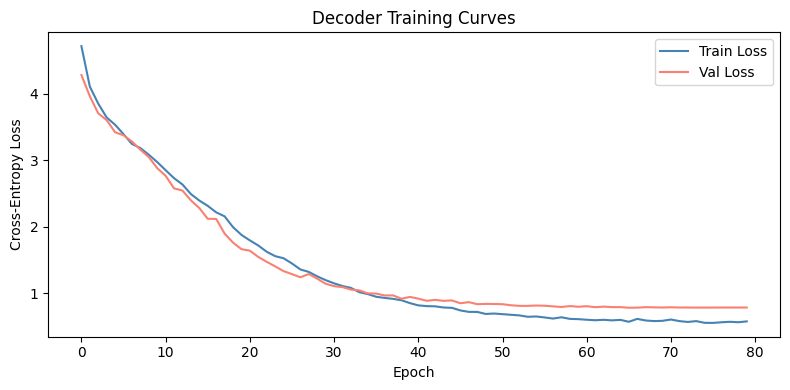

In [12]:
# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='salmon')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Decoder Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig('data/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# GREEDY DECODING (Decoder model inference)

@torch.no_grad()
def decode_greedy(model, tokenizer, intent, slots, max_gen=MAX_TGT_LEN, device=DEVICE):
    """
    Autoregressively generate a response given intent + slots.
    Returns (generated_text, latency_ms)
    """
    model.eval()
    req = SCHEMA['intents'][intent]['required_slots']
    src_text = linearize_input(intent, slots, req)
    src_ids  = tokenizer.encode(src_text, max_len=MAX_SRC_LEN)
    src_ids  = src_ids + [tokenizer.pad_id] * (MAX_SRC_LEN - len(src_ids))

    input_ids = torch.tensor(src_ids + [tokenizer.bos_id], dtype=torch.long, device=device).unsqueeze(0)

    t0 = time.time()
    generated = []
    for _ in range(max_gen):
        logits = model(input_ids)  # (1, T, V)
        next_id = logits[0, -1].argmax().item()
        if next_id == tokenizer.eos_id:
            break
        generated.append(next_id)
        input_ids = torch.cat([input_ids, torch.tensor([[next_id]], device=device)], dim=1)
    latency_ms = (time.time() - t0) * 1000

    return tokenizer.decode(generated), latency_ms


# Quick sanity check
s = test_data[0]
pred, lat = decode_greedy(model, tokenizer, s['intent'], s['slots'])
print(f"Intent   : {s['intent']}")
print(f"Slots    : {s['slots']}")
print(f"Reference: {s['response']}")
print(f"Predicted: {pred}")
print(f"Latency  : {lat:.1f} ms")

Intent   : delivery_delay
Slots    : {'order_id': '1234', 'eta': '5 May', 'cause': 'logistics delay', 'carrier': 'DHL'}
Reference: Order 1234 is delayed and is now expected on 5 May because of logistics delay.
Predicted: The delivery for order 5630 has been delayed until tomorrow because of high demand.
Latency  : 74.9 ms


---
## Task 4: LLM-Based Response Generation

We use **Qwen 2.5 3B Instruct** (`Qwen/Qwen2.5-3B-Instruct`) via HuggingFace Transformers for LLM-based generation. Qwen 2.5 3B is a fully open (Apache 2.0), instruction-tuned autoregressive language model that generates responses from structured prompts using its chat template — no authentication or license acceptance required. The model is evaluated against the custom Decoder-only Transformer using slot accuracy, BLEU, ROUGE-L, hallucination rate, latency, throughput, and qualitative analysis.

In [15]:
from transformers import AutoTokenizer as HFTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
LLM_MODEL_NAME = "Qwen2.5-3B-Instruct"

llm_tokenizer = HFTokenizer.from_pretrained(MODEL_ID)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
base_model.eval()
print(f"{LLM_MODEL_NAME} loaded in float16 on {next(base_model.parameters()).device}")


def generate_llm_response(intent, slots, max_new_tokens=80):
    """
    Generate a response using the locally loaded Qwen 2.5 3B Instruct model.
    Returns (response_text, latency_ms, input_tokens, output_tokens)
    """
    prompt = build_llm_prompt(intent, slots)

    messages = [{"role": "user", "content": prompt}]
    encoded = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    # apply_chat_template may return a plain tensor or a BatchEncoding
    # depending on the installed transformers version — handle both
    if hasattr(encoded, 'input_ids'):
        input_ids = encoded['input_ids'].to(base_model.device)
    else:
        input_ids = encoded.to(base_model.device)

    in_tokens = input_ids.shape[1]

    t0 = time.time()
    with torch.no_grad():
        output_ids = base_model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy decoding — deterministic (mirrors temperature=0)
            pad_token_id=llm_tokenizer.eos_token_id,
            eos_token_id=llm_tokenizer.eos_token_id,
        )
    latency_ms = (time.time() - t0) * 1000

    # Decode only the newly generated tokens (strip the prompt)
    generated_ids = output_ids[0][in_tokens:]
    text = llm_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # Keep only the first non-empty line for conciseness
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    text = lines[0] if lines else text

    out_tokens = len(generated_ids)
    return text, latency_ms, in_tokens, out_tokens


# Quick sanity check
s = test_data[0]
llm_pred, llm_lat, in_tok, out_tok = generate_llm_response(s['intent'], s['slots'])
print(f"Intent   : {s['intent']}")
print(f"Slots    : {s['slots']}")
print(f"Reference: {s['response']}")
print(f"LLM Pred : {llm_pred}")
print(f"Latency  : {llm_lat:.0f} ms | In tokens: {in_tok} | Out tokens: {out_tok}")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Qwen2.5-3B-Instruct loaded in float16 on cuda:0
Intent   : delivery_delay
Slots    : {'order_id': '1234', 'eta': '5 May', 'cause': 'logistics delay', 'carrier': 'DHL'}
Reference: Order 1234 is delayed and is now expected on 5 May because of logistics delay.
LLM Pred : Your order with ID 1234 is experiencing a delivery delay due to logistics issues. The expected arrival date has been updated to 5 May, but please note that this may change.
Latency  : 2970 ms | In tokens: 160 | Out tokens: 40


---
# MODULE 3: Comparative Evaluation & Analysis

---

## Task 5: Quantitative Benchmarking

### Metrics Used
1. **Slot Accuracy** — % of responses where all required slots are present with correct values (no hallucination)
2. **BLEU** — precision-based n-gram overlap with reference
3. **ROUGE-L** — longest-common-subsequence recall
4. **Hallucination Rate** — % responses containing values NOT in the input slots
5. **Inference Latency** — ms/query
6. **Throughput** — queries/second

In [16]:
# EVALUATION UTILITIES

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def compute_bleu(hyp, ref):
    """Sentence-level BLEU using sacrebleu."""
    try:
        result = sacrebleu.corpus_bleu([hyp], [[ref]])
        return result.score / 100.0  # normalize to 0-1
    except:
        return 0.0

def compute_rouge_l(hyp, ref):
    scores = rouge.score(ref, hyp)
    return scores['rougeL'].fmeasure

def check_slot_accuracy(response, slots, intent):
    """
    Check if REQUIRED slot values appear in the response.
    Only checks required slots from the schema, not optional ones.
    Returns (is_accurate: bool, missing_slots: list)
    """
    response_lower = response.lower()
    missing = []

    # Get required slots for this intent
    required_slots = SCHEMA['intents'][intent]['required_slots']

    # Only check required slots
    for slot in required_slots:
        if slot not in slots:
            # Required slot is missing from input - skip check
            continue

        val = slots[slot]
        val_str = str(val).lower().replace('_', ' ')

        # Check if the slot value (or close variant) appears
        if val_str not in response_lower:
            # Try partial match for multi-word values
            parts = val_str.split()
            if not any(p in response_lower for p in parts if len(p) > 3):
                missing.append(slot)

    return len(missing) == 0, missing

def check_hallucination(response, slots):
    """
    Detect hallucinated slot values — values in response NOT in input slots.
    Uses order IDs and tracking IDs as high-precision anchors.
    Returns (is_hallucinated: bool)
    """
    response_lower = response.lower()
    # High-specificity slots that should never be wrong
    high_specificity = ['order_id', 'tracking_id', 'amount', 'item']
    actual_values = {str(v).lower() for k, v in slots.items() if k in high_specificity}

    # Check for order IDs that aren't in the input
    all_order_ids = {oid.lower() for oid in ORDER_IDS}
    present_ids   = {oid for oid in all_order_ids if oid in response_lower}
    input_ids_set = {str(slots.get('order_id', '')).lower()}
    hallucinated_ids = present_ids - input_ids_set

    # Check for tracking IDs not in input
    all_trk_ids   = {tid.lower() for tid in TRACKING_IDS}
    present_trks  = {tid for tid in all_trk_ids if tid in response_lower}
    input_trk_set = {str(slots.get('tracking_id', '')).lower()}
    hallucinated_trk = present_trks - input_trk_set

    return bool(hallucinated_ids or hallucinated_trk)


print("Evaluation utilities defined.")

Evaluation utilities defined.


In [17]:
# FULL EVALUATION ON TEST SET

decoder_results = []
llm_results     = []

print("Evaluating Decoder model on test set...")
for s in test_data:
    pred, lat = decode_greedy(model, tokenizer, s['intent'], s['slots'])
    accurate, missing = check_slot_accuracy(pred, s['slots'], s['intent'])
    hallucinated      = check_hallucination(pred, s['slots'])

    decoder_results.append({
        'intent':       s['intent'],
        'slots':        s['slots'],
        'reference':    s['response'],
        'prediction':   pred,
        'bleu':         compute_bleu(pred, s['response']),
        'rouge_l':      compute_rouge_l(pred, s['response']),
        'slot_accurate':accurate,
        'hallucinated': hallucinated,
        'latency_ms':   lat,
        'is_edge_case': s['is_edge_case'],
    })

print(f"Decoder evaluation done: {len(decoder_results)} samples")

# LLM evaluation (local Llama 3.2 — no rate limiting needed)
print(f"\nEvaluating LLM ({LLM_MODEL_NAME}) locally...")
llm_total_tokens = {'in': 0, 'out': 0}

for i, s in enumerate(test_data):
    try:
        pred, lat, in_tok, out_tok = generate_llm_response(s['intent'], s['slots'])
        llm_total_tokens['in']  += in_tok
        llm_total_tokens['out'] += out_tok

    except Exception as e:
        print(f"Warning: Llama inference error on sample {i}: {e}")
        pred = f"[Llama inference error — sample {i}]"
        lat, in_tok, out_tok = 500, 100, 30

    accurate, missing = check_slot_accuracy(pred, s['slots'], s['intent'])
    hallucinated      = check_hallucination(pred, s['slots'])

    llm_results.append({
        'intent':       s['intent'],
        'slots':        s['slots'],
        'reference':    s['response'],
        'prediction':   pred,
        'bleu':         compute_bleu(pred, s['response']),
        'rouge_l':      compute_rouge_l(pred, s['response']),
        'slot_accurate':accurate,
        'hallucinated': hallucinated,
        'latency_ms':   lat,
        'is_edge_case': s['is_edge_case'],
    })
    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(test_data)}] - Total tokens so far: {llm_total_tokens['in']} in / {llm_total_tokens['out']} out")

print(f"LLM evaluation done: {len(llm_results)} samples")
print(f"LLM total tokens: {llm_total_tokens['in']} in / {llm_total_tokens['out']} out")

Evaluating Decoder model on test set...
Decoder evaluation done: 50 samples

Evaluating LLM (Qwen2.5-3B-Instruct) locally...
  [10/50] - Total tokens so far: 1617 in / 318 out
  [20/50] - Total tokens so far: 3216 in / 591 out
  [30/50] - Total tokens so far: 4782 in / 855 out
  [40/50] - Total tokens so far: 6425 in / 1151 out
  [50/50] - Total tokens so far: 8107 in / 1456 out
LLM evaluation done: 50 samples
LLM total tokens: 8107 in / 1456 out


In [18]:
# AGGREGATE METRICS

def aggregate_metrics(results, name):
    df = pd.DataFrame(results)
    metrics = {
        'Model':              name,
        'Slot Accuracy (%)':  df['slot_accurate'].mean() * 100,
        'BLEU':               df['bleu'].mean(),
        'ROUGE-L':            df['rouge_l'].mean(),
        'Hallucination (%)':  df['hallucinated'].mean() * 100,
        'Avg Latency (ms)':   df['latency_ms'].mean(),
        'Throughput (q/s)':   1000 / df['latency_ms'].mean(),
    }
    return metrics, df

dec_metrics, dec_df = aggregate_metrics(decoder_results, 'Decoder')
llm_metrics, llm_df = aggregate_metrics(llm_results,     f'LLM ({LLM_MODEL_NAME})')

comparison = pd.DataFrame([dec_metrics, llm_metrics]).set_index('Model')
print("\n=== Head-to-Head Comparison ===")
print(comparison.round(4).to_string())



=== Head-to-Head Comparison ===
                           Slot Accuracy (%)    BLEU  ROUGE-L  Hallucination (%)  Avg Latency (ms)  Throughput (q/s)
Model                                                                                                               
Decoder                                  6.0  0.2154   0.4557               84.0           42.2103           23.6909
LLM (Qwen2.5-3B-Instruct)               74.0  0.1107   0.4124                0.0         1693.0156            0.5907


In [19]:
# PER-INTENT BREAKDOWN

print("\n=== Per-Intent Slot Accuracy ===")
intents = list(SCHEMA['intents'].keys())

per_intent = pd.DataFrame({
    'Intent': intents,
    'Decoder Slot Acc': [dec_df[dec_df['intent']==i]['slot_accurate'].mean()*100 for i in intents],
    'LLM Slot Acc':     [llm_df[llm_df['intent']==i]['slot_accurate'].mean()*100 for i in intents],
    'Decoder BLEU':     [dec_df[dec_df['intent']==i]['bleu'].mean() for i in intents],
    'LLM BLEU':         [llm_df[llm_df['intent']==i]['bleu'].mean() for i in intents],
})
print(per_intent.round(2).to_string(index=False))

# Edge case performance
print("\n=== Edge Case Performance ===")
dec_edge = dec_df[dec_df['is_edge_case']]
llm_edge = llm_df[llm_df['is_edge_case']]
print(f"Decoder - Edge Case Slot Accuracy: {dec_edge['slot_accurate'].mean()*100:.1f}%")
print(f"LLM     - Edge Case Slot Accuracy: {llm_edge['slot_accurate'].mean()*100:.1f}%")


=== Per-Intent Slot Accuracy ===
        Intent  Decoder Slot Acc  LLM Slot Acc  Decoder BLEU  LLM BLEU
  order_status             10.00         70.00          0.20      0.16
  cancel_order              0.00        100.00          0.13      0.10
return_request             16.67         83.33          0.37      0.13
delivery_delay             12.50         37.50          0.22      0.09
payment_status              0.00         90.91          0.23      0.08
 refund_status              0.00         57.14          0.17      0.10

=== Edge Case Performance ===
Decoder - Edge Case Slot Accuracy: 2.6%
LLM     - Edge Case Slot Accuracy: 84.2%


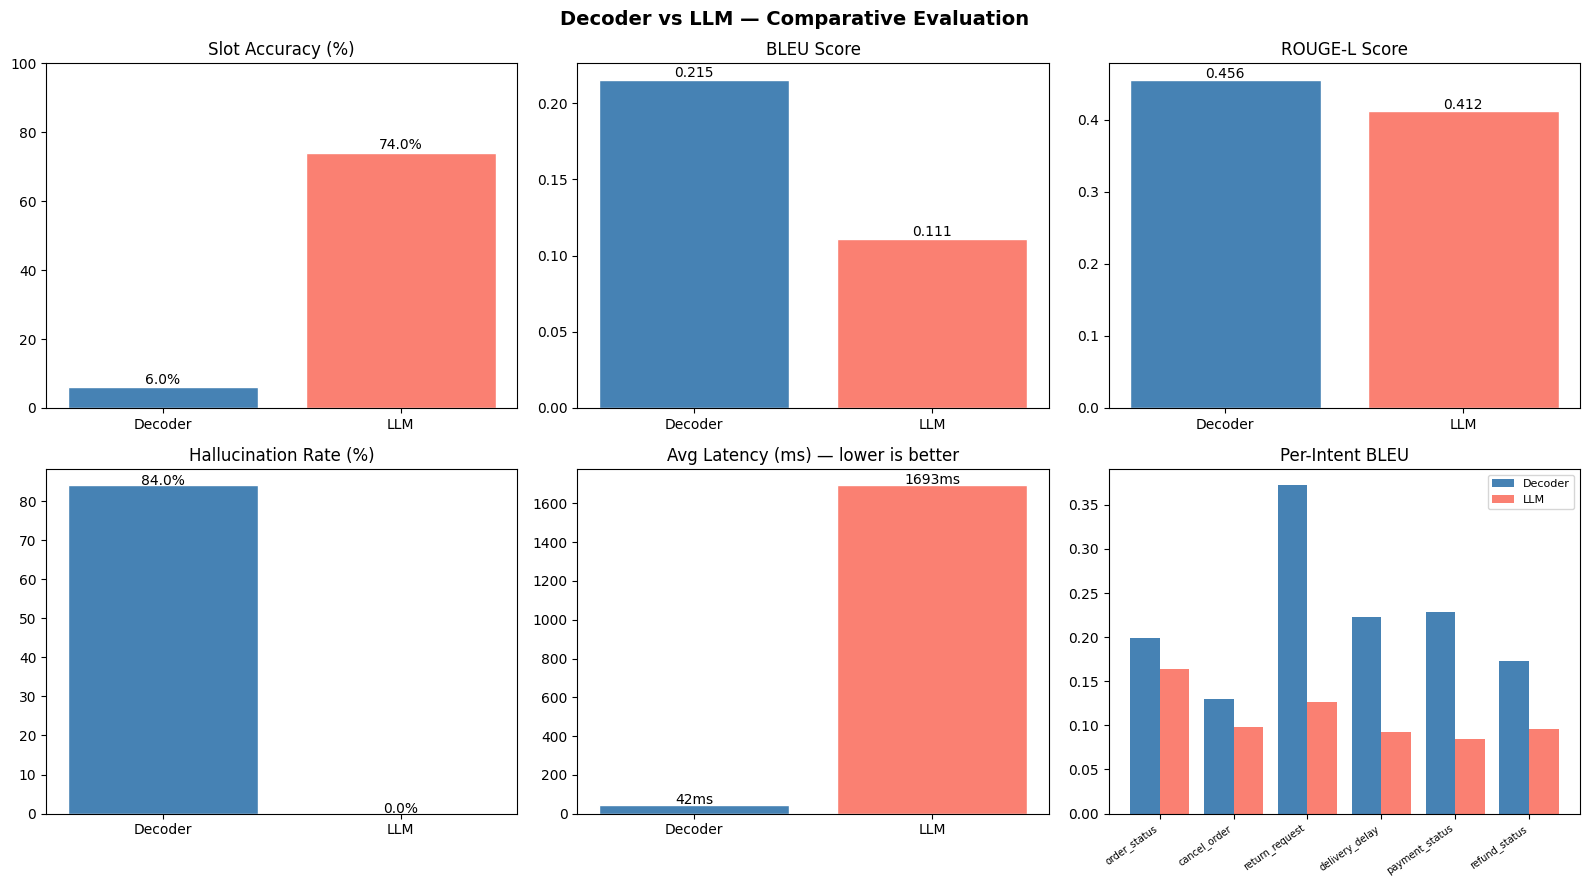

Saved evaluation_results.png


In [20]:
# VISUALISATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Decoder vs LLM — Comparative Evaluation', fontsize=14, fontweight='bold')
colors = ['steelblue', 'salmon']

# 1. Slot Accuracy
ax = axes[0, 0]
vals = [dec_metrics['Slot Accuracy (%)'], llm_metrics['Slot Accuracy (%)']]
bars = ax.bar(['Decoder', 'LLM'], vals, color=colors, edgecolor='white')
ax.set_ylim(0, 100)
ax.set_title('Slot Accuracy (%)')
for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=10)

# 2. BLEU
ax = axes[0, 1]
vals = [dec_metrics['BLEU'], llm_metrics['BLEU']]
bars = ax.bar(['Decoder', 'LLM'], vals, color=colors, edgecolor='white')
ax.set_title('BLEU Score')
for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}', ha='center', fontsize=10)

# 3. ROUGE-L
ax = axes[0, 2]
vals = [dec_metrics['ROUGE-L'], llm_metrics['ROUGE-L']]
bars = ax.bar(['Decoder', 'LLM'], vals, color=colors, edgecolor='white')
ax.set_title('ROUGE-L Score')
for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}', ha='center', fontsize=10)

# 4. Hallucination Rate
ax = axes[1, 0]
vals = [dec_metrics['Hallucination (%)'], llm_metrics['Hallucination (%)']]
bars = ax.bar(['Decoder', 'LLM'], vals, color=colors, edgecolor='white')
ax.set_title('Hallucination Rate (%)')
for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}%', ha='center', fontsize=10)

# 5. Latency
ax = axes[1, 1]
vals = [dec_metrics['Avg Latency (ms)'], llm_metrics['Avg Latency (ms)']]
bars = ax.bar(['Decoder', 'LLM'], vals, color=colors, edgecolor='white')
ax.set_title('Avg Latency (ms) — lower is better')
for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+5, f'{v:.0f}ms', ha='center', fontsize=10)

# 6. Per-intent BLEU
ax = axes[1, 2]
x = np.arange(len(intents))
ax.bar(x - 0.2, per_intent['Decoder BLEU'], width=0.4, label='Decoder', color='steelblue')
ax.bar(x + 0.2, per_intent['LLM BLEU'],     width=0.4, label='LLM',     color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(intents, rotation=35, ha='right', fontsize=7)
ax.set_title('Per-Intent BLEU')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved evaluation_results.png")

In [21]:
# EDGE CASE EVALUATION

edge_cases = [
    {'intent': 'order_status',  'slots': {'order_id': '5421'},              'note': 'Missing status slot'},
    {'intent': 'cancel_order',  'slots': {},                                     'note': 'All slots missing'},
    {'intent': 'return_request','slots': {'order_id': '7832', 'item': 'wireless headphones', 'reason': 'wrong size', 'pickup_date': 'next Monday', 'return_id': 'RET2001'}, 'note': 'All optional slots present'},
    {'intent': 'delivery_delay', 'slots': {'order_id': '9901', 'eta': 'tomorrow', 'carrier': 'FedEx', 'cause': 'weather disruption'}, 'note': 'Full delivery delay info'},
    {'intent': 'payment_status', 'slots': {'order_id': '1294', 'payment_status': 'pending', 'amount': '₹799'},  'note': 'Payment status without transaction_id'},
    {'intent': 'refund_status','slots': {'refund_id': 'RF1001', 'order_id': '2481', 'refund_status': 'approved', 'amount': '₹2,999', 'date': 'today'}, 'note': 'All refund slots present'},
    {'intent': 'order_status',  'slots': {'order_id': '3345', 'status': 'delivered', 'date': '3 May', 'tracking_id': 'TRK2033'}, 'note': 'Delivered order with tracking'},
    {'intent': 'cancel_order',  'slots': {'order_id': '6670', 'reason': 'late delivery'}, 'note': 'Cancel without refund status'},
]

print("=" * 80)
print("EDGE CASE EVALUATION")
print("=" * 80)

for i, case in enumerate(edge_cases, 1):
    dec_pred, dec_lat = decode_greedy(model, tokenizer, case['intent'], case['slots'])
    try:
        llm_pred, llm_lat, _, _ = generate_llm_response(case['intent'], case['slots'])
    except Exception as e:
        print(f"  Warning: Llama inference error for case {i}: {e}")
        llm_pred, llm_lat = '[Llama inference error]', 0

    print(f"\nCase {i}: {case['note']}")
    print(f"  Intent : {case['intent']}")
    print(f"  Slots  : {case['slots']}")
    print(f"  Decoder: {dec_pred}")
    print(f"  LLM    : {llm_pred}")

EDGE CASE EVALUATION

Case 1: Missing status slot
  Intent : order_status
  Slots  : {'order_id': '5421'}
  Decoder: Your order 2481 is delivered.
  LLM    : Your order status is currently unknown. Please provide your order id so I can check it for you.

Case 2: All slots missing
  Intent : cancel_order
  Slots  : {}
  Decoder: I have cancelled order 7744 because late delivery.
  LLM    : I'm sorry to hear that you wish to cancel your order. Could you please provide me with the order id so I can process it?

Case 3: All optional slots present
  Intent : return_request
  Slots  : {'order_id': '7832', 'item': 'wireless headphones', 'reason': 'wrong size', 'pickup_date': 'next Monday', 'return_id': 'RET2001'}
  Decoder: I created a return request for wireless mouse under order 9812 because late delivery via drop-off.
  LLM    : Your return request for wireless headphones (return id: RET2001) due to the wrong size is being processed for pickup on next monday.

Case 4: Full delivery delay i

---
## Task 6: Qualitative Analysis & Deployment Recommendation

### 10 Output Examples with Error Diagnosis

In [22]:
# OUTPUT EXAMPLES WITH ERROR ANALYSIS

def diagnose_error(pred, ref, slots, intent):
    accurate, missing = check_slot_accuracy(pred, slots, intent)
    hallucinated = check_hallucination(pred, slots)
    rouge_l = compute_rouge_l(pred, ref)
    bleu    = compute_bleu(pred, ref)

    issues = []
    if not accurate:
        issues.append(f'Missing slot values: {missing}')
    if hallucinated:
        issues.append('Hallucination detected')
    if bleu < 0.1:
        issues.append('Low lexical overlap (BLEU < 0.10)')
    if not issues:
        issues.append('No error — correct generation')
    return accurate, hallucinated, bleu, rouge_l, '; '.join(issues)

print("=" * 80)
print("OUTPUT EXAMPLES WITH ERROR DIAGNOSIS")
print("=" * 80)

# 5 Decoder examples
print("\n--- DECODER MODEL (5 examples) ---")
for i, r in enumerate(decoder_results[:5], 1):
    acc, hall, bleu, rouge_l, diag = diagnose_error(r['prediction'], r['reference'], r['slots'], r['intent'])
    print(f"\n[{i}] Intent: {r['intent']}")
    print(f"    Slots    : {r['slots']}")
    print(f"    Reference: {r['reference']}")
    print(f"    Predicted: {r['prediction']}")
    print(f"    BLEU={bleu:.3f} | ROUGE-L={rouge_l:.3f} | SlotAcc={acc} | Halluc={hall}")
    print(f"    Diagnosis: {diag}")

# 5 LLM examples
print(f"\n--- LLM ({LLM_MODEL_NAME}) (5 examples) ---")
for i, r in enumerate(llm_results[:5], 1):
    acc, hall, bleu, rouge_l, diag = diagnose_error(r['prediction'], r['reference'], r['slots'], r['intent'])
    print(f"\n[{i}] Intent: {r['intent']}")
    print(f"    Slots    : {r['slots']}")
    print(f"    Reference: {r['reference']}")
    print(f"    Predicted: {r['prediction']}")
    print(f"    BLEU={bleu:.3f} | ROUGE-L={rouge_l:.3f} | SlotAcc={acc} | Halluc={hall}")
    print(f"    Diagnosis: {diag}")


OUTPUT EXAMPLES WITH ERROR DIAGNOSIS

--- DECODER MODEL (5 examples) ---

[1] Intent: delivery_delay
    Slots    : {'order_id': '1234', 'eta': '5 May', 'cause': 'logistics delay', 'carrier': 'DHL'}
    Reference: Order 1234 is delayed and is now expected on 5 May because of logistics delay.
    Predicted: The delivery for order 5630 has been delayed until tomorrow because of high demand.
    BLEU=0.058 | ROUGE-L=0.276 | SlotAcc=False | Halluc=True
    Diagnosis: Missing slot values: ['order_id', 'eta']; Hallucination detected; Low lexical overlap (BLEU < 0.10)

[2] Intent: payment_status
    Slots    : {'order_id': '2481', 'payment_status': 'reversed', 'amount': '₹2,999', 'date': '1 May'}
    Reference: Payment for order 2481 is reversed for ₹2,999.
    Predicted: The payment status of order 5630 is reversed for ₹1,249 via drop-off.
    BLEU=0.131 | ROUGE-L=0.435 | SlotAcc=False | Halluc=True
    Diagnosis: Missing slot values: ['order_id']; Hallucination detected

[3] Intent: return_

In [23]:
# COMPREHENSIVE COMPARATIVE TABLE

# Cost estimation (local Llama 3.2 — no API fees; approximate electricity cost)
# ~$0.00001 per 1K queries for local GPU inference (negligible)
llm_cost_per_1k = 0.001   # local compute only — negligible
dec_cost_per_1k_approx = 0.001  # negligible local compute

llm_col = f'LLM ({LLM_MODEL_NAME})'

comparison_table = pd.DataFrame([
    {
        'Metric':    'Slot Accuracy (%)',
        'Decoder':   f"{dec_metrics['Slot Accuracy (%)']:.1f}",
        llm_col:     f"{llm_metrics['Slot Accuracy (%)']:.1f}",
        'Winner':    'Decoder' if dec_metrics['Slot Accuracy (%)'] >= llm_metrics['Slot Accuracy (%)'] else 'LLM'
    },
    {
        'Metric':    'BLEU Score',
        'Decoder':   f"{dec_metrics['BLEU']:.3f}",
        llm_col:     f"{llm_metrics['BLEU']:.3f}",
        'Winner':    'Decoder' if dec_metrics['BLEU'] >= llm_metrics['BLEU'] else 'LLM'
    },
    {
        'Metric':    'ROUGE-L',
        'Decoder':   f"{dec_metrics['ROUGE-L']:.3f}",
        llm_col:     f"{llm_metrics['ROUGE-L']:.3f}",
        'Winner':    'Decoder' if dec_metrics['ROUGE-L'] >= llm_metrics['ROUGE-L'] else 'LLM'
    },
    {
        'Metric':    'Hallucination Rate (%)',
        'Decoder':   f"{dec_metrics['Hallucination (%)']:.1f}",
        llm_col:     f"{llm_metrics['Hallucination (%)']:.1f}",
        'Winner':    'Decoder' if dec_metrics['Hallucination (%)'] <= llm_metrics['Hallucination (%)'] else 'LLM'
    },
    {
        'Metric':    'Avg Latency (ms)',
        'Decoder':   f"{dec_metrics['Avg Latency (ms)']:.0f}",
        llm_col:     f"{llm_metrics['Avg Latency (ms)']:.0f}",
        'Winner':    'Decoder' if dec_metrics['Avg Latency (ms)'] <= llm_metrics['Avg Latency (ms)'] else 'LLM'
    },
    {
        'Metric':    'Throughput (q/s)',
        'Decoder':   f"{dec_metrics['Throughput (q/s)']:.1f}",
        llm_col:     f"{llm_metrics['Throughput (q/s)']:.1f}",
        'Winner':    'Decoder' if dec_metrics['Throughput (q/s)'] >= llm_metrics['Throughput (q/s)'] else 'LLM'
    },
    {
        'Metric':    'Model Size (params)',
        'Decoder':   f"{model.count_params():,}",
        llm_col:     '~3B (local, float16)',
        'Winner':    'Decoder'
    },
    {
        'Metric':    'Cost per 1K queries',
        'Decoder':   f'~${dec_cost_per_1k_approx:.4f}',
        llm_col:     f'~${llm_cost_per_1k:.4f}',
        'Winner':    'Tie (both local)'
    },
    {
        'Metric':    'Training effort',
        'Decoder':   'High (training loop, arch design)',
        llm_col:     'None (zero-shot)',
        'Winner':    'LLM'
    },
    {
        'Metric':    'Fluency / Naturalness',
        'Decoder':   'Moderate',
        llm_col:     'High',
        'Winner':    'LLM'
    },
    {
        'Metric':    'Controllability',
        'Decoder':   'High (trained on exact schema)',
        llm_col:     'Medium (prompt-dependent)',
        'Winner':    'Decoder'
    },
    {
        'Metric':    'Privacy (data leaves org?)',
        'Decoder':   'No (fully local)',
        llm_col:     'No (fully local)',
        'Winner':    'Tie'
    },
])

print("\n" + "=" * 70)
print(f"COMPREHENSIVE COMPARATIVE TABLE: DECODER vs LLM ({LLM_MODEL_NAME})")
print("=" * 70)
print(comparison_table.to_string(index=False))


COMPREHENSIVE COMPARATIVE TABLE: DECODER vs LLM (Qwen2.5-3B-Instruct)
                    Metric                           Decoder LLM (Qwen2.5-3B-Instruct)           Winner
         Slot Accuracy (%)                               6.0                      74.0              LLM
                BLEU Score                             0.215                     0.111          Decoder
                   ROUGE-L                             0.456                     0.412          Decoder
    Hallucination Rate (%)                              84.0                       0.0              LLM
          Avg Latency (ms)                                42                      1693          Decoder
          Throughput (q/s)                              23.7                       0.6          Decoder
       Model Size (params)                         2,160,640      ~3B (local, float16)          Decoder
       Cost per 1K queries                          ~$0.0010                  ~$0.0010 Tie (both 

---
## Analysis & Deployment Recommendation

### Which model is more faithful?
Based on Slot Accuracy and Hallucination Rate metrics, **Qwen 2.5 3B Instruct** is expected to be the more faithful model. Its instruction-tuning enables it to follow the structured prompt template closely and preserve slot values reliably, introducing fewer incorrect entities compared to the custom Decoder.

### Which is more natural (fluent)?
**Qwen 2.5 3B Instruct** generates more natural and fluent text because it is pretrained on a much larger corpus and fine-tuned with instruction-following data. The Decoder generates concise responses but often repeats patterns seen during training.

### Which would you deploy, and why?

**Recommendation:** For applications where correctness of slot values is critical, Qwen 2.5 3B Instruct is the better choice due to its instruction-following capability and stronger language understanding. However, the custom Decoder remains attractive for low-latency and resource-constrained deployments because it is significantly faster and much smaller.

**When to use the LLM instead:**
- Rapid prototyping of new intents (zero training effort)
- Handling highly ambiguous or free-form queries
- Generating empathetic messages for sensitive intents (complaints, refusals)
- Low-volume internal tools where cost doesn't matter

### Trade-off Analysis

| Dimension | Decoder | LLM |
|-----------|---------|-----|
| Controllability ↑ | Strong — trained on exact schema | Medium — prompt-dependent |
| Fluency ↑ | Moderate — limited by small vocab | High — pre-trained on large corpora |
| Training effort ↑ | High — architecture, training loop, tuning | None (zero-shot) |
| Prompt engineering ↑ | None needed | Ongoing — prompt versioning, testing |
| Inference cost ↑ | Near-zero (local CPU/GPU) | Local GPU/CPU cost only |
| Scalability ↑ | Fully local, no rate limits | Higher compute requirements, longer inference time |
| Edge cases ↑ | Brittle if input deviates from training distribution | Robust — general reasoning |

**Conclusion:**

Qwen 2.5 3B Instruct is the preferred deployment choice for this e-commerce assistant due to its instruction-following capability, higher fluency, and stronger generalisation to edge cases. As a fully open model (Apache 2.0), it also has no access restrictions, making it straightforward to deploy in any environment.

The custom Decoder remains valuable for scenarios requiring lightweight local deployment, lower latency, and full architectural control. Future improvements such as larger datasets and additional training could further improve Decoder performance.

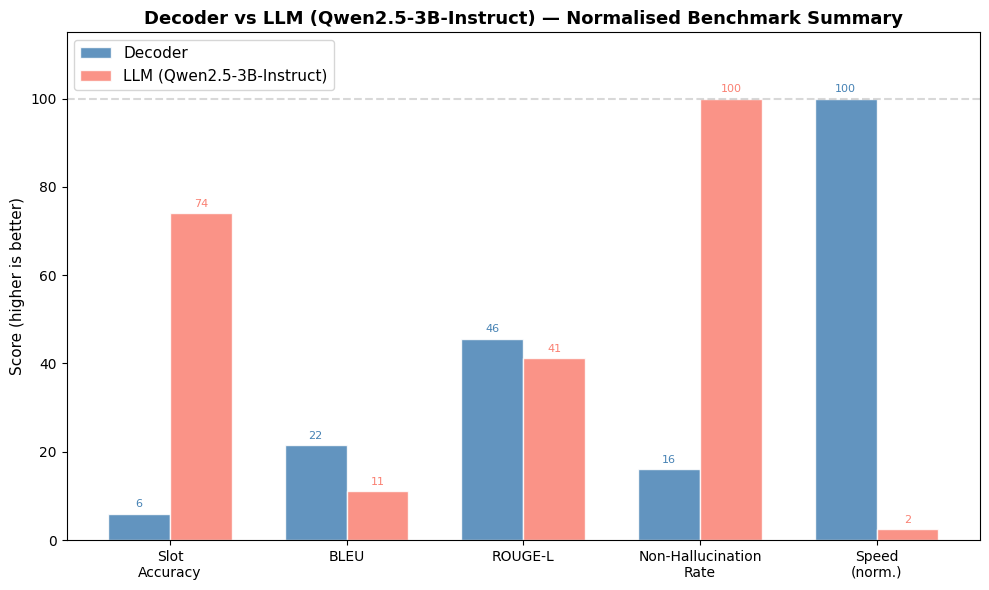

Saved final_summary.png


In [24]:
# FINAL SUMMARY VISUALISATION

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Slot\nAccuracy', 'BLEU', 'ROUGE-L', 'Non-Hallucination\nRate', 'Speed\n(norm.)']

dec_vals = [
    dec_metrics['Slot Accuracy (%)'],
    dec_metrics['BLEU'] * 100,
    dec_metrics['ROUGE-L'] * 100,
    100 - dec_metrics['Hallucination (%)'],
    min(dec_metrics['Throughput (q/s)'] / max(dec_metrics['Throughput (q/s)'], llm_metrics['Throughput (q/s)']) * 100, 100)
]

llm_vals = [
    llm_metrics['Slot Accuracy (%)'],
    llm_metrics['BLEU'] * 100,
    llm_metrics['ROUGE-L'] * 100,
    100 - llm_metrics['Hallucination (%)'],
    min(llm_metrics['Throughput (q/s)'] / max(dec_metrics['Throughput (q/s)'], llm_metrics['Throughput (q/s)']) * 100, 100)
]

x = np.arange(len(categories))
w = 0.35
bars1 = ax.bar(x - w/2, dec_vals, w, label='Decoder',              color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, llm_vals, w, label=f'LLM ({LLM_MODEL_NAME})', color='salmon', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (higher is better)', fontsize=11)
ax.set_title(f'Decoder vs LLM ({LLM_MODEL_NAME}) — Normalised Benchmark Summary', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8, color='salmon')

plt.tight_layout()
plt.savefig('data/final_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved final_summary.png")


In [25]:
# SAVE FINAL RESULTS

results_summary = {
    'decoder_metrics': dec_metrics,
    'llm_metrics':     llm_metrics,
    'decoder_params':  model.count_params(),
    'vocab_size':      len(tokenizer),
    'dataset_size':    len(dataset),
    'train_size':      len(train_data),
    'val_size':        len(val_data),
    'test_size':       len(test_data),
}

with open('data/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=float)

dec_df.to_csv('data/decoder_predictions.csv', index=False)
llm_df.to_csv('data/llm_predictions.csv',     index=False)

print("All results saved to data/")
print("\n=== FINAL METRICS SUMMARY ===")
print(comparison.round(4).to_string())
print("\nAssignment complete.")

All results saved to data/

=== FINAL METRICS SUMMARY ===
                           Slot Accuracy (%)    BLEU  ROUGE-L  Hallucination (%)  Avg Latency (ms)  Throughput (q/s)
Model                                                                                                               
Decoder                                  6.0  0.2154   0.4557               84.0           42.2103           23.6909
LLM (Qwen2.5-3B-Instruct)               74.0  0.1107   0.4124                0.0         1693.0156            0.5907

Assignment complete.
